# Instrucciones para elaborar la tarea modelo

La tarea modelo se elaborará en un notebook de Jupyter, empleando la interfaz HAPI Client (Heliophysics Data Application Programmer's Interface). Esta es una interfaz, principalmente para Python, utilizada para acceder, descargar y graficar datos de series temporales desde servidores de datos de Heliofísica, siguiendo la especificación HAPI. La tarea deberá incluir lo siguiente:

## Objetivo
Sintetizar la cadena completa de eventos, desde una erupción solar (llamarada/CME) hasta sus efectos en la Tierra (tormenta geomagnética, perturbación ionosférica), para predecir los impactos tecnológicos potenciales de un evento real de clima espacial del **5 al 8 de marzo de 2012**.

## Metodología
El análisis se realizará mediante:

1. **Selección del evento**: Identificación de CMEs de halo completo con velocidad ≥1000 km/s durante el período seleccionado
2. **Modelado computacional**: Ejecución de modelos en CCMC (CORHEL-CME, Tsyganenko TS05, IRI-2020, trayectorias de rayos cósmicos)
3. **Análisis de datos observacionales**: Descarga y visualización de datos mediante HAPI Client:
   - Índice Dst (tormenta geomagnética)
   - Magnetómetros terrestres (INTERMAGNET)
   - Parámetros del viento solar (ACE, Geotail, OMNI)
   - Campo magnético interplanetario (ACE MFI)
   - Perturbaciones ionosféricas (GPS ROTI)
   - Imágenes coronográficas (LASCO C3)
4. **Síntesis**: Correlación temporal entre la CME, llegada del viento solar, y efectos terrestres

## Resultados
Los resultados incluirán:
- Gráficos de series temporales de parámetros del viento solar
- Evolución del índice Dst durante la tormenta geomagnética
- Respuesta de los magnetómetros terrestres
- Perturbaciones en la ionosfera medidas por GPS
- Salidas de los modelos CCMC mostrando la propagación de la CME y los efectos en la magnetosfera/ionosfera

## Conclusiones
Se presentarán las conclusiones sobre:
- La efectividad del evento como tormenta geomagnética
- Los tiempos de llegada observados vs. predichos
- Los impactos potenciales en sistemas tecnológicos (satélites, comunicaciones, redes eléctricas)
- La utilidad de los modelos para predicción operacional del clima espacial

# Metodología

## Selección de la CME

Para este análisis se seleccionó el período del **5 al 8 de marzo de 2012**, durante el cual ocurrieron múltiples eyecciones de masa coronal (CMEs) de halo completo con velocidades superiores a 1000 km/s.

### Búsqueda en la lista CDAW de CMEs de Halo

Utilizando la [lista de CME de halo de LASCO/SOHO](https://cdaw.gsfc.nasa.gov/CME_list/halo/halo.html), se identificaron **16 CMEs** durante el período 2012/03/05 00:00:00 a 2012/03/08 00:00:00.

Aplicando los criterios de selección:
- Velocidad lineal ≥ 1000 km/s
- Ancho angular = 360° (halo completo)
- Aceleración en rango específico (-2000 a -1 m/s²)

Se identificaron **3 CMEs principales**:

| Fecha y Hora (UTC) | Velocidad Lineal (km/s) | Velocidad Final (km/s) | Aceleración (m/s²) | Ángulo PA Central (°) | Masa (g) | Energía Cinética (erg) |
|-------------------|------------------------|----------------------|-------------------|---------------------|----------|---------------------|
| 2012/03/05 04:00:05 | 1531 | 1400 | -24.60 | 61 | 1.40×10¹⁶ | 1.60×10³² |
| **2012/03/07 00:24:06** | **2684** | **2379** | **-88.20** | **57** | **1.40×10¹⁶** | **5.00×10³²** |
| 2012/03/07 01:30:24 | 1825 | 1468 | -160.90 | 82 | 7.40×10¹⁵ | 1.20×10³² |

### CME Principal Seleccionada

La **CME más potente** ocurrió el **7 de marzo de 2012 a las 00:24:06 UTC**, con:
- Velocidad lineal: **2684 km/s**
- Velocidad final (ajuste de 2do orden): **2379 km/s**
- Energía cinética: **5.00×10³² erg**

Esta CME fue clasificada como evento de halo completo (360°) y está asociada con una llamarada solar de clase X5.4 que ocurrió aproximadamente al mismo tiempo.

### Período de Análisis

- **Inicio**: 5 de marzo de 2012, 00:00:00 UTC (incluye la primera CME significativa)
- **Fin**: 8 de marzo de 2012, 00:00:00 UTC (3 días completos)
- **CME principal para modelado**: 7 de marzo de 2012, 00:24:06 UTC
- **Fecha para modelos de magnetosfera e ionosfera**: 10 de marzo de 2012 (3 días después de la CME principal)

## Simulaciones de Modelos CCMC

Para caracterizar completamente la cadena de eventos del clima espacial, se realizaron solicitudes de "Run-on-request" en el Community Coordinated Modeling Center (CCMC) de la NASA para los siguientes modelos:

### 1. Modelo de CME: CORHEL-CME
- **URL del modelo**: https://ccmc.gsfc.nasa.gov/models/CORHEL-CME~1/
- **Fecha y hora de entrada**: 7 de marzo de 2012, 00:24:06 UTC
- **Parámetros**: CME con velocidad inicial de 2684 km/s, ángulo de posición central 57°
- **Propósito**: Simular la propagación de la CME desde la corona solar hasta la órbita terrestre

### 2. Modelo de Magnetosfera: Tsyganenko TS05
- **URL del modelo**: https://ccmc.gsfc.nasa.gov/models/Tsyganenko%20Magnetic%20Field~TS05/
- **Fecha y hora de entrada**: 10 de marzo de 2012 (3 días después de la CME)
- **Propósito**: Modelar la configuración del campo magnético terrestre durante la tormenta geomagnética

### 3. Modelo de Ionosfera: IRI-2020
- **URL del modelo**: https://ccmc.gsfc.nasa.gov/models/IRI~2020/
- **Fecha y hora de entrada**: 10 de marzo de 2012 (3 días después de la CME)
- **Propósito**: Simular las perturbaciones ionosféricas causadas por la tormenta geomagnética

### 4. Trayectorias de Rayos Cósmicos
- **URL del modelo**: https://cor.crmodels.org/geo-mag/
- **Modelos utilizados**: Tsyganenko T05 + IGRF
- **Fecha**: 10 de marzo de 2012
- **Propósito**: Calcular las trayectorias de partículas energéticas durante la tormenta

**Nota**: Los resultados de estas simulaciones se deben descargar y guardar en la carpeta del proyecto para ser subidos al repositorio GitLab junto con este notebook.

# Paquetes a instalar en su entorno virtual (antes de abrir el Jupyter Notebook)

## Cree su entorno virtual de trabajo

1. Abra el Miniforge Prompt desde el menú de Windows o desde una ventana de terminal de Linux (Ctrl+Alt+T) y navegue a la carpeta de su proyecto.

2. Cree el entorno con el comando venv (se recomienda nombrar la carpeta como hapienv para ocultarla o reconocerla fácilmente):

In [1]:
!python -m venv hapienv

3. Active el entorno virtual para instalar los paquetes

In [2]:
#Windows: 
hapienv\Scripts\Activate

SyntaxError: unexpected character after line continuation character (448752644.py, line 2)

In [3]:
#macOS/Linux: 
!source .venv/bin/activate

## Instalar hapiclient y hapiplot

In [4]:
!pip install --upgrade hapiclient hapiplot

## Instalar pytz 
Esta es una biblioteca de terceros para Python que permite el manejo preciso y la conversión de zonas horarias al trabajar con fechas y horas (datetime). Proporciona acceso a la base de datos de zonas horarias de la IANA (Olson) y facilita la gestión de los cambios de horario de verano. 

In [5]:
!pip install --upgrade pytz

## Instalar enlilviz

enlilviz es un paquete de Python para visualizar la salida del código de viento solar Enlil.

In [6]:
#https://enlilviz.readthedocs.io/en/latest/examples.html
!pip install enlilviz
#git clone git://github.com/SWxTREC/enlilviz
#curl -OJL https://github.com/SWxTREC/enlilviz/tarball/master
#curl -OJL https://github.com/SWxTREC/enlilviz/tarball/master
#python setup.py install

## Instalar el Jupyter Notebook:

In [7]:
!pip install --upgrade jupyterlab

## Abrir el jupyter notebook

In [8]:
!jupyter lab

[I 2026-03-07 15:19:37.606 ServerApp] jupyter_lsp | extension was successfully linked.
[I 2026-03-07 15:19:37.607 ServerApp] jupyter_server_terminals | extension was successfully linked.
[I 2026-03-07 15:19:37.609 ServerApp] jupyterlab | extension was successfully linked.
[I 2026-03-07 15:19:37.610 ServerApp] Writing Jupyter server cookie secret to /Users/tonalidae/Library/Jupyter/runtime/jupyter_cookie_secret
[I 2026-03-07 15:19:37.692 ServerApp] notebook_shim | extension was successfully linked.
[I 2026-03-07 15:19:37.724 ServerApp] notebook_shim | extension was successfully loaded.
[I 2026-03-07 15:19:37.725 ServerApp] jupyter_lsp | extension was successfully loaded.
[I 2026-03-07 15:19:37.726 ServerApp] jupyter_server_terminals | extension was successfully loaded.
[I 2026-03-07 15:19:37.727 LabApp] JupyterLab extension loaded from /Volumes/T7/tarea3-astroparticulas/.venv/lib/python3.14/site-packages/jupyterlab
[I 2026-03-07 15:19:37.727 LabApp] JupyterLab application directory is /

In [ ]:
## Llamar los paquetes que se necesitarán

In [9]:
from hapiclient import hapi 
from hapiplot import hapiplot
from hapiclient.util import pythonshell

# Lista de servidores y comando de ayuda

[https://hapi-server.org/all_.txt]

#help(hapi) #desplegará documentación de ayuda de hapiclient

# Análisis de Datos Observacionales con HAPI Client

A continuación se utilizan datos de servidores HAPI para analizar las mediciones reales durante el evento de clima espacial.

## Graficar el Dst

In [16]:
start = '2012-03-05T00:00:00Z'  # Fecha y hora de inicio
stop = '2012-03-08T00:00:00Z'   # Fecha y hora de finalización
server1 = 'https://iswa.gsfc.nasa.gov/IswaSystemWebApp/hapi'  # servidor HAPI
dataset1 = 'dst_final'  # nombre del set de datos
#dataset1 = 'dst_provisional' # en caso de que no exista el final
#meta1 = hapi(server1,dataset1) 
#display(meta1) # Para ver los parámetros que contiene el dataset
opts = {'logging': False, 'usecache': True, 'cachedir': './hapicache'}

#Extraer los valores de Dst deseados

In [17]:
from hapiclient import hapi
parameters1 = 'Dst' #parámetros a extraer
data1, meta1 = hapi(server1, dataset1, parameters1, start, stop)

In [18]:
#Convertir el tiempo del dataset en tiempo datetime (año, mes, día, hora, minuto)
from hapiclient import hapitime2datetime
dateTimes1 = hapitime2datetime(data1['Time'])

Para imprimir el Dst

,Dst
Time,
2012-03-05 00:00:00+00:00,-30.0
2012-03-05 01:00:00+00:00,-32.0
2012-03-05 02:00:00+00:00,-33.0
2012-03-05 03:00:00+00:00,-33.0
2012-03-05 04:00:00+00:00,-35.0
...,...
2012-03-07 19:00:00+00:00,-66.0
2012-03-07 20:00:00+00:00,-68.0
2012-03-07 21:00:00+00:00,-63.0


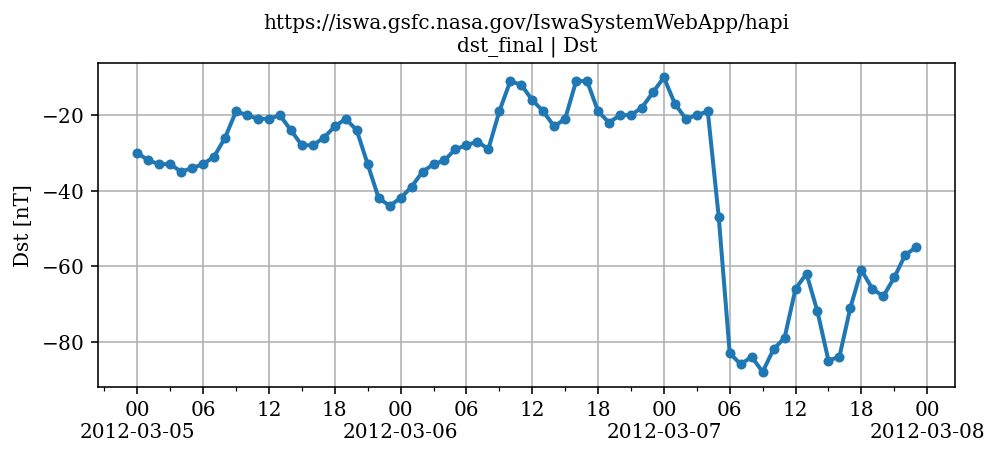

{'HAPI': '2.0',
 'status': {'code': 1200, 'message': 'OK'},
 'title': 'Final Dst via WDC, Kyoto',
 'description': 'Final Dst via WDC, Kyoto',
 'startDate': '1957-01-01T00:00:00Z',
 'stopDate': '2020-12-31T23:00:00Z',
 'parameters': [{'fill': 'null',
   'length': 22,
   'name': 'Time',
   'type': 'isotime',
   'units': 'UTC'},
  {'fill': '9999',
   'name': 'Dst',
   'type': 'double',
   'units': 'nT',
   'description': 'Disturbance Storm Time Index',
   'hapiplot': {'figure': <Figure size 1008x432 with 1 Axes>}}],
 'x_server': 'https://iswa.gsfc.nasa.gov/IswaSystemWebApp/hapi',
 'x_dataset': 'dst_final',
 'x_parameters': 'Dst',
 'x_time.min': '2012-03-05T00:00:00Z',
 'x_time.max': '2012-03-08T00:00:00Z',
 'x_requestDate': '2026-03-07T15:26:23',
 'x_cacheDir': '/var/folders/5x/xq48d9_j5k3549b62z8sv1b80000gn/T/hapi-data/iswa.gsfc.nasa.gov_IswaSystemWebApp_hapi',
 'x_downloadTime': 0.39266037940979004,
 'x_readTime': 0.0018749237060546875,
 'x_metaFileParsed': '/var/folders/5x/xq48d9_j5k35

In [19]:
import pandas
# Create dataframe
df1 = pandas.DataFrame(data1)

# Add column to DataFrame
df1['Time'] = dateTimes1

# Set index
df1.set_index('Time', inplace=True)

# Rename columns
#df1.columns = ['Time', 'Dst']

display(df1) #IMprime el data frame

hapiplot(data1,meta1) #Imprime el gráfico (dataDST) y la metadata

## Imprimir la magnitud del campo magnético en varios observatorios de INTERMAGNET

In [20]:
#Visualizar los parámetros del dataset de San Juan, Puerto Rico de 1 minuto de cadencia
server2 = "https://imag-data.bgs.ac.uk/GIN_V1/hapi"
dataset21 = "abk/best-avail/PT1M/hdzf"
dataset22 = "mea/best-avail/PT1M/hdzf"
dataset23 = "sjg/best-avail/PT1M/hdzf"
dataset24 = "hua/best-avail/PT1M/hdzf"
dataset25 = "kep/best-avail/PT1M/hdzf"
meta21 = hapi(server2,dataset21) 
display(meta21) #Para ver los parámetros que contiene el dataset

{'HAPI': '3.1',
 'status': {'code': 1200, 'message': 'ok'},
 'parameters': [{'name': 'Time',
   'type': 'isotime',
   'length': 17,
   'units': 'UTC',
   'fill': None,
   'description': 'The UTC date and time for the data from Abisko, Sweden (ABK)',
   'label': 'Date/time'},
  {'name': 'Field_Vector',
   'type': 'double',
   'size': [3],
   'units': ['nT', 'minutes', 'nT'],
   'coordinateSystemName': 'Cylindrical',
   'vectorComponents': ['rho', 'longitude', 'z'],
   'fill': '99999.0',
   'description': 'The vector value of the magnetic field at Abisko, Sweden (ABK), for definitions of the vector components see https://intermagnet.org/faq/10.geomagnetic-comp.html',
   'label': ['H', 'D', 'Z']},
  {'name': 'Field_Magnitude',
   'type': 'double',
   'units': 'nT',
   'vectorComponents': 'r',
   'fill': '99999.0',
   'description': 'The scalar value of the magnetic field from an independent instrument at Abisko, Sweden (ABK)',
   'label': 'F'}],
 'startDate': '1994-01-01T00:00:00Z',
 'sto

In [21]:
parameters2 = 'Field_Magnitude'
start = '2012-03-05T00:00:00Z'
stop = '2012-03-08T00:00:00Z'
data21, meta21 = hapi(server2, dataset21, parameters2, start, stop)
data22, meta22 = hapi(server2, dataset22, parameters2, start, stop)
data23, meta23 = hapi(server2, dataset23, parameters2, start, stop)
data24, meta24 = hapi(server2, dataset24, parameters2, start, stop)
data25, meta25 = hapi(server2, dataset25, parameters2, start, stop)
hapiplot(data21,meta21)
hapiplot(data22,meta22)
hapiplot(data23,meta23)
hapiplot(data24,meta24)
hapiplot(data25,meta25)

HAPIError: HAPI error 1405: time outside valid range


In [22]:
##Graficar la magnitud del campo magnético interplanetario medido por ACE 

In [23]:
#Visualizar los parámetros del dataset de ACE
server3 = "https://cdaweb.gsfc.nasa.gov/hapi"
dataset3 = 'AC_H0_MFI'
meta3 = hapi(server3,dataset3) 
display(meta3) #Para ver los parámetros que contiene el dataset
#parameters3 = 'Magnitude'
#data3, meta3 = hapi(server3, dataset3, parameters3, start, stop)
#hapiplot(data3,meta3)

{'HAPI': '2.0',
 'resourceURL': 'https://cdaweb.gsfc.nasa.gov/misc/NotesA.html#AC_H0_MFI',
 'contact': 'N. Ness @ Bartol Research Institute',
 'parameters': [{'name': 'Time',
   'length': 24,
   'units': 'UTC',
   'type': 'isotime',
   'fill': None},
  {'name': 'Magnitude',
   'description': 'B-field magnitude',
   'units': 'nT',
   'type': 'double',
   'fill': '-1.0E31'},
  {'size': [3],
   'name': 'BGSEc',
   'description': 'Magnetic Field Vector in GSE Cartesian coordinates (16 sec)',
   'units': 'nT',
   'type': 'double',
   'fill': '-1.0E31'},
  {'size': [3],
   'name': 'BGSM',
   'description': 'Magnetic field vector in GSM coordinates (16 sec)',
   'units': 'nT',
   'type': 'double',
   'fill': '-1.0E31'},
  {'name': 'dBrms',
   'description': 'RMS of Magnetic Field (16 sec period)',
   'units': 'nT',
   'type': 'double',
   'fill': '-1.0E31'},
  {'size': [3],
   'name': 'SC_pos_GSE',
   'description': 'ACE s/c position, 3 comp. in GSE coord.',
   'units': 'km',
   'type': 'doub

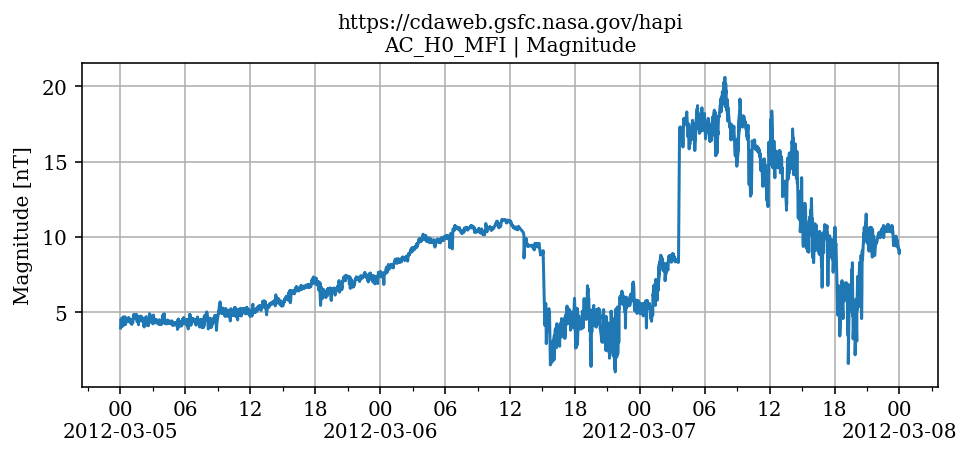

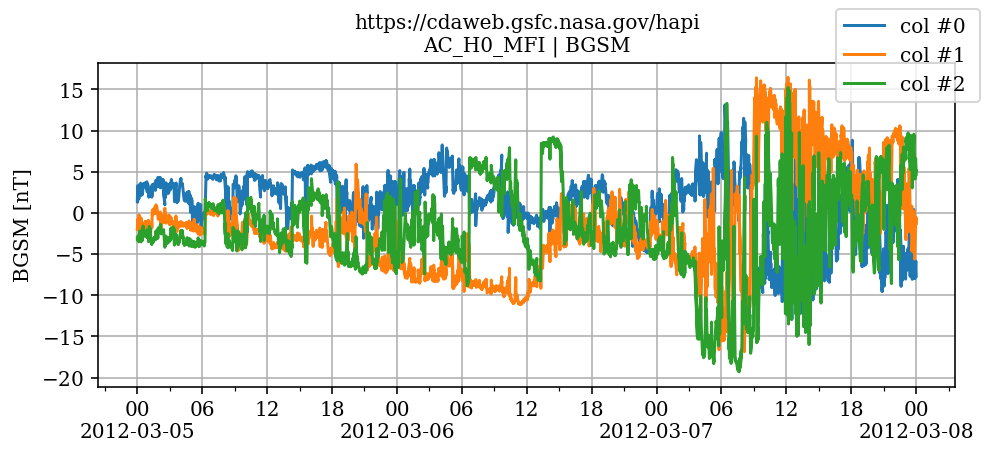

{'HAPI': '2.0',
 'resourceURL': 'https://cdaweb.gsfc.nasa.gov/misc/NotesA.html#AC_H0_MFI',
 'contact': 'N. Ness @ Bartol Research Institute',
 'parameters': [{'name': 'Time',
   'length': 24,
   'units': 'UTC',
   'type': 'isotime',
   'fill': None},
  {'name': 'Magnitude',
   'description': 'B-field magnitude',
   'units': 'nT',
   'type': 'double',
   'fill': '-1.0E31',
   'hapiplot': {'figure': <Figure size 1008x432 with 1 Axes>}},
  {'size': [3],
   'name': 'BGSM',
   'description': 'Magnetic field vector in GSM coordinates (16 sec)',
   'units': 'nT',
   'type': 'double',
   'fill': '-1.0E31',
   'hapiplot': {'figure': <Figure size 1008x432 with 1 Axes>}}],
 'startDate': '1997-09-02T00:00:12Z',
 'stopDate': '2026-02-23T23:59:57Z',
 'status': {'code': 1200, 'message': 'OK'},
 'x_server': 'https://cdaweb.gsfc.nasa.gov/hapi',
 'x_dataset': 'AC_H0_MFI',
 'x_parameters': 'Magnitude,BGSM',
 'x_time.min': '2012-03-05T00:00:00Z',
 'x_time.max': '2012-03-08T00:00:00Z',
 'x_requestDate': '2

In [24]:
parameters3 = 'Magnitude,BGSM' #Magnitud del campo magnético interplanetario
data3, meta3 = hapi(server3, dataset3, parameters3, start, stop)
hapiplot(data3,meta3)

In [25]:
#Visualizar los parámetros del dataset de ACE
server4 = "https://cdaweb.gsfc.nasa.gov/hapi"
dataset4 = 'GE_K0_CPI'
meta4 = hapi(server4,dataset4) 
display(meta4) #Para ver los parámetros que contiene el dataset
#parameters3 = 'SW_P_Den,SW_V,W' #Plasma number density, ion velocity, pressure
#data3, meta3 = hapi(server3, dataset3, parameters3, start, stop)
#hapiplot(data3,meta3)

{'HAPI': '2.0',
 'resourceURL': 'https://cdaweb.gsfc.nasa.gov/misc/NotesG.html#GE_K0_CPI',
 'contact': 'L. Frank @ U. Iowa',
 'parameters': [{'name': 'Time',
   'length': 24,
   'units': 'UTC',
   'type': 'isotime',
   'fill': None},
  {'name': 'SW_P_Den',
   'description': 'Ion number density (Solar Wind Analyzer), scalar',
   'units': '/cm**3',
   'type': 'double',
   'fill': '-1.0E31'},
  {'name': 'SW_P_AVGE',
   'description': 'Ion Average Energy (Solar Wind Anal. s/c frame), scalar',
   'units': 'eV',
   'type': 'double',
   'fill': '-1.0E31'},
  {'size': [3],
   'name': 'SW_V',
   'description': 'Ion bulk flow velocity, 3 ~GSE cartesian components (SWA)',
   'units': 'km/sec',
   'type': 'double',
   'fill': '-1.0E31'},
  {'name': 'HP_P_Den',
   'description': 'Ion Number Density (Hot Plasma 2D Anal), scalar ',
   'units': '/cm**3',
   'type': 'double',
   'fill': '-1.0E31'},
  {'name': 'HP_P_AVGE',
   'description': 'Ion Average Energy (Hot Plasma 2D Anal), scalar',
   'units': 

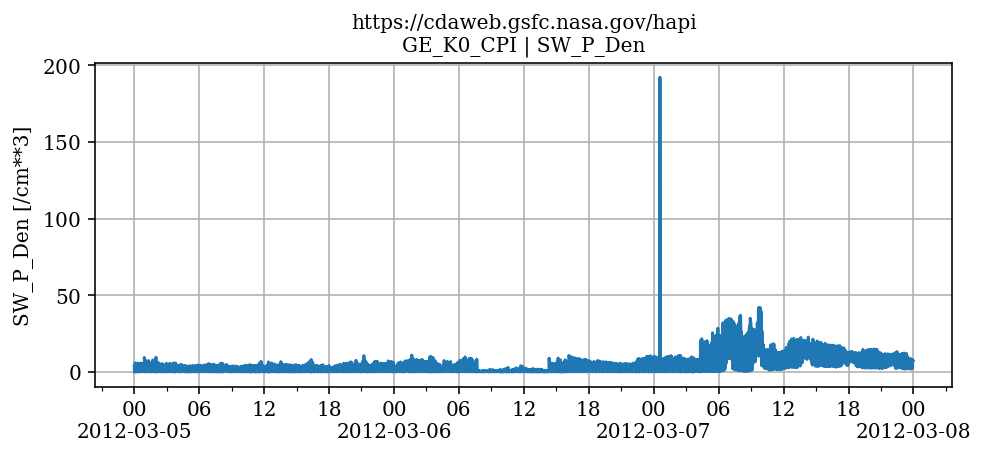

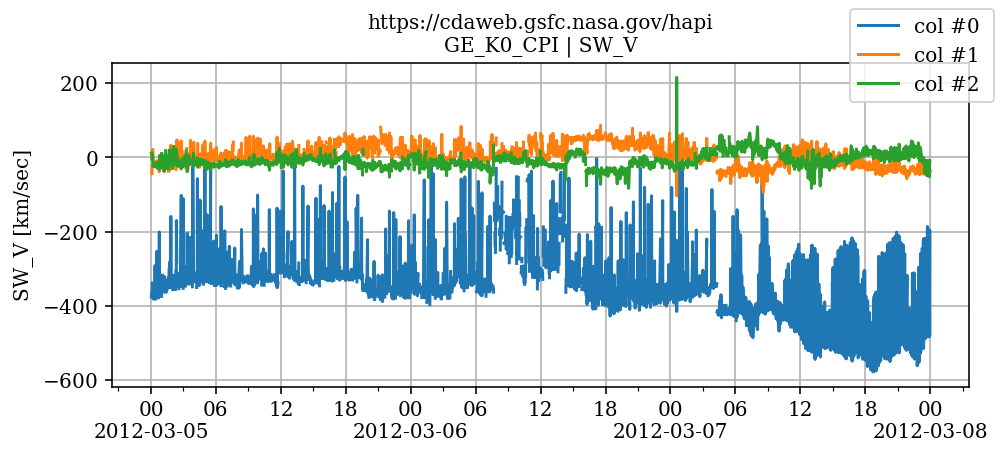

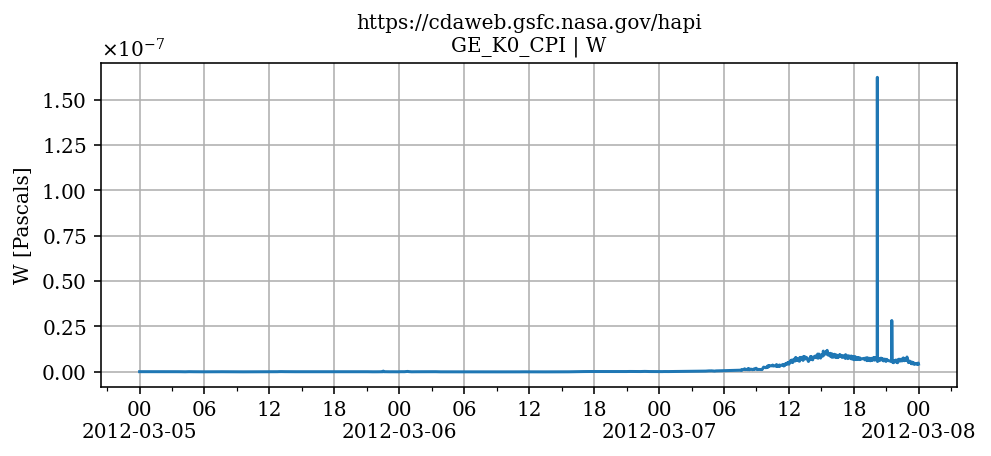

{'HAPI': '2.0',
 'resourceURL': 'https://cdaweb.gsfc.nasa.gov/misc/NotesG.html#GE_K0_CPI',
 'contact': 'L. Frank @ U. Iowa',
 'parameters': [{'name': 'Time',
   'length': 24,
   'units': 'UTC',
   'type': 'isotime',
   'fill': None},
  {'name': 'SW_P_Den',
   'description': 'Ion number density (Solar Wind Analyzer), scalar',
   'units': '/cm**3',
   'type': 'double',
   'fill': '-1.0E31',
   'hapiplot': {'figure': <Figure size 1008x432 with 1 Axes>}},
  {'size': [3],
   'name': 'SW_V',
   'description': 'Ion bulk flow velocity, 3 ~GSE cartesian components (SWA)',
   'units': 'km/sec',
   'type': 'double',
   'fill': '-1.0E31',
   'hapiplot': {'figure': <Figure size 1008x432 with 1 Axes>}},
  {'name': 'W',
   'description': 'Plasma Pressure (Hot Plasma 2D Anal) scalar',
   'units': 'Pascals',
   'type': 'double',
   'fill': '-1.0E31',
   'hapiplot': {'figure': <Figure size 1008x432 with 1 Axes>}}],
 'startDate': '1992-09-08T07:30:40Z',
 'stopDate': '2022-06-27T12:22:28Z',
 'status': {'c

In [26]:
parameters4 = 'SW_P_Den,SW_V,W' #Plasma number density, ion velocity, pressure
data4, meta4 = hapi(server4, dataset4, parameters4, start, stop)
hapiplot(data4,meta4)

In [27]:
#Visualizar los parámetros del dataset de ACE
server5 = "https://cdaweb.gsfc.nasa.gov/hapi"
dataset5 = 'AC_K0_EPM'
meta5 = hapi(server5,dataset5) 
display(meta5) #Para ver los parámetros que contiene el dataset

{'HAPI': '2.0',
 'resourceURL': 'https://cdaweb.gsfc.nasa.gov/misc/NotesA.html#AC_K0_EPM',
 'contact': 'R. Gold @ JHU Applied Physics Laboratory',
 'parameters': [{'name': 'Time',
   'length': 24,
   'units': 'UTC',
   'type': 'isotime',
   'fill': None},
  {'name': 'H_lo',
   'description': 'Proton Flux (0.48-0.97 MeV)',
   'units': '1/(cm2 s ster MeV)',
   'type': 'double',
   'fill': '-1.0E31'},
  {'name': 'Ion_very_lo',
   'description': 'Ion Flux (47-65 keV)',
   'units': '1/(cm2 s ster MeV)',
   'type': 'double',
   'fill': '-1.0E31'},
  {'name': 'Ion_lo',
   'description': 'Ion Flux (112-187 keV)',
   'units': '1/(cm2 s ster MeV)',
   'type': 'double',
   'fill': '-1.0E31'},
  {'name': 'Ion_mid',
   'description': 'Ion Flux (310-580 keV)',
   'units': '1/(cm2 s ster MeV)',
   'type': 'double',
   'fill': '-1.0E31'},
  {'name': 'Ion_hi',
   'description': 'Ion Flux (1060-1910 keV)',
   'units': '1/(cm2 s ster MeV)',
   'type': 'double',
   'fill': '-1.0E31'},
  {'name': 'Electron

In [28]:
#Visualizar los parámetros del dataset de ACE
server5 = "https://cdaweb.gsfc.nasa.gov/hapi"
dataset5 = 'AC_K0_EPM'
meta5 = hapi(server5,dataset5) 
display(meta5) #Para ver los parámetros que contiene el dataset

{'HAPI': '2.0',
 'resourceURL': 'https://cdaweb.gsfc.nasa.gov/misc/NotesA.html#AC_K0_EPM',
 'contact': 'R. Gold @ JHU Applied Physics Laboratory',
 'parameters': [{'name': 'Time',
   'length': 24,
   'units': 'UTC',
   'type': 'isotime',
   'fill': None},
  {'name': 'H_lo',
   'description': 'Proton Flux (0.48-0.97 MeV)',
   'units': '1/(cm2 s ster MeV)',
   'type': 'double',
   'fill': '-1.0E31'},
  {'name': 'Ion_very_lo',
   'description': 'Ion Flux (47-65 keV)',
   'units': '1/(cm2 s ster MeV)',
   'type': 'double',
   'fill': '-1.0E31'},
  {'name': 'Ion_lo',
   'description': 'Ion Flux (112-187 keV)',
   'units': '1/(cm2 s ster MeV)',
   'type': 'double',
   'fill': '-1.0E31'},
  {'name': 'Ion_mid',
   'description': 'Ion Flux (310-580 keV)',
   'units': '1/(cm2 s ster MeV)',
   'type': 'double',
   'fill': '-1.0E31'},
  {'name': 'Ion_hi',
   'description': 'Ion Flux (1060-1910 keV)',
   'units': '1/(cm2 s ster MeV)',
   'type': 'double',
   'fill': '-1.0E31'},
  {'name': 'Electron

In [29]:
server6 = "https://cdaweb.gsfc.nasa.gov/hapi"
dataset6 = 'GPS_ROTI15MIN_JPL'
meta6 = hapi(server6,dataset6)
display(meta6)

{'HAPI': '2.0',
 'resourceURL': 'https://cdaweb.gsfc.nasa.gov/misc/NotesG.html#GPS_ROTI15MIN_JPL',
 'contact': 'Xiaoqing Pi @ Jet Propulsion Laboratory',
 'parameters': [{'name': 'Time',
   'length': 24,
   'units': 'UTC',
   'type': 'isotime',
   'fill': None},
  {'bins': [{'name': 'lat',
     'centers': [-90.0,
      -87.5,
      -85.0,
      -82.5,
      -80.0,
      -77.5,
      -75.0,
      -72.5,
      -70.0,
      -67.5,
      -65.0,
      -62.5,
      -60.0,
      -57.5,
      -55.0,
      -52.5,
      -50.0,
      -47.5,
      -45.0,
      -42.5,
      -40.0,
      -37.5,
      -35.0,
      -32.5,
      -30.0,
      -27.5,
      -25.0,
      -22.5,
      -20.0,
      -17.5,
      -15.0,
      -12.5,
      -10.0,
      -7.5,
      -5.0,
      -2.5,
      0.0,
      2.5,
      5.0,
      7.5,
      10.0,
      12.5,
      15.0,
      17.5,
      20.0,
      22.5,
      25.0,
      27.5,
      30.0,
      32.5,
      35.0,
      37.5,
      40.0,
      42.5,
      45.0,
      47.

In [30]:
parameters6 = 'rotimedM_South'
start = '2012-03-05T00:00:00Z'
stop  = '2012-03-08T00:00:00Z'
opts       = {'logging': False, 'usecache': True, 'cachedir': './hapicache'}
data6,meta6 = hapi(server6, dataset6, parameters6, start, stop, **opts)
hapiplot(data6,meta6)

HAPIError: Problem with time data. First value: b"\x93NUMPY\x01\x00\xb6\x00{'descr': [('T"


In [ ]:
server7 = "https://cdaweb.gsfc.nasa.gov/hapi"
dataset7 = 'OMNI_HRO2_5MIN'
meta7 = hapi(server7,dataset7)
display(meta7)

{'HAPI': '2.0',
 'resourceURL': 'https://cdaweb.gsfc.nasa.gov/misc/NotesO.html#OMNI_HRO2_5MIN',
 'contact': 'J.H. King, N. Papatashvilli @ AdnetSystems, NASA GSFC',
 'parameters': [{'name': 'Time',
   'length': 24,
   'units': 'UTC',
   'type': 'isotime',
   'fill': None},
  {'name': 'IMF',
   'description': 'OMNI ID code for the source spacecraft for time-shifted IMF values (see OMNI documentation link for codes)',
   'units': None,
   'type': 'integer',
   'fill': '99'},
  {'name': 'PLS',
   'description': 'OMNI ID code for the source spacecraft for time-shifted IP plasma values (see OMNI documentation link for codes)',
   'units': None,
   'type': 'integer',
   'fill': '99'},
  {'name': 'IMF_PTS',
   'description': 'Number of fine time scale points in IMF averages',
   'units': None,
   'type': 'integer',
   'fill': '999'},
  {'name': 'PLS_PTS',
   'description': 'Number of fine time scale points in plasma averages',
   'units': None,
   'type': 'integer',
   'fill': '999'},
  {'nam

In [31]:
parameters7 = 'F,BZ_GSM,flow_speed,proton_density,T,Pressure,PR-FLX_10,PR-FLX_30,PR-FLX_60'
start = '2012-03-05T00:00:00Z'
stop  = '2012-03-08T00:00:00Z'
opts       = {'logging': False, 'usecache': True, 'cachedir': './hapicache'}
data7,meta7 = hapi(server7, dataset7, parameters7, start, stop, **opts)
hapiplot(data7,meta7)

NameError: name 'server7' is not defined

In [32]:
server8 = 'https://iswa.gsfc.nasa.gov/IswaSystemWebApp/hapi'
dataset8 = 'NOAA_KP_P3H'
meta8 = hapi(server8,dataset8)
display(meta8)

{'HAPI': '2.0',
 'status': {'code': 1200, 'message': 'OK'},
 'title': 'NOAA SWPC 3-hourly observed, estimated, and predicted Kp',
 'description': 'The Observed, Estimated, and Predicted 3-hour Planetary Kp-index is derived at the NOAA Space Weather Prediction Center using data from ground-based magnetometers via this URL: https://services.swpc.noaa.gov/products/noaa-planetary-k-index-forecast.json',
 'startDate': '1994-01-01T00:00:00Z',
 'stopDate': '2026-03-10T00:00:00Z',
 'parameters': [{'fill': 'null',
   'length': 22,
   'name': 'Time',
   'type': 'isotime',
   'units': 'UTC'},
  {'fill': '-1',
   'name': 'KP_3H',
   'type': 'float',
   'units': 'KP Index',
   'description': 'KP for 3 hour windows, timestamp is for the end of the 3 hour window.  For example 06:00 timestamp is for 03:00 to 06:00'},
  {'fill': 'null',
   'name': 'Kp_observed',
   'type': 'double',
   'units': 'unitless',
   'description': 'Observed 3-hourly Kp'},
  {'fill': 'null',
   'name': 'Kp_estimated',
   'type

hapi(): Running hapi.py version 0.2.6
hapi(): file directory = ./hapicache/iswa.gsfc.nasa.gov_IswaSystemWebApp_hapi
hapi(): Reading ./hapicache/iswa.gsfc.nasa.gov_IswaSystemWebApp_hapi
hapi(): Writing NOAA_KP_P3H___.json 
hapi(): Writing NOAA_KP_P3H___.pkl 
hapi(): Reading https://iswa.gsfc.nasa.gov/IswaSystemWebApp/hapi/capabilities
hapi(): Writing https://iswa.gsfc.nasa.gov/IswaSystemWebApp/hapi/data?id=NOAA_KP_P3H&parameters=Kp_observed&time.min=2012-03-05T00:00:00Z&time.max=2012-03-08T00:00:00Z to NOAA_KP_P3H_Kp_observed_20120305T000000_20120308T000000.csv
hapi(): Reading and parsing NOAA_KP_P3H_Kp_observed_20120305T000000_20120308T000000.csv
hapi(): Writing ./hapicache/iswa.gsfc.nasa.gov_IswaSystemWebApp_hapi/NOAA_KP_P3H_Kp_observed_20120305T000000_20120308T000000.pkl
hapi(): Writing ./hapicache/iswa.gsfc.nasa.gov_IswaSystemWebApp_hapi/NOAA_KP_P3H_Kp_observed_20120305T000000_20120308T000000.npy


,Time,Kp_observed
0,b'2012-03-05T00:00:00Z',2.0
1,b'2012-03-05T03:00:00Z',2.0
2,b'2012-03-05T06:00:00Z',2.0
3,b'2012-03-05T09:00:00Z',2.0
4,b'2012-03-05T12:00:00Z',1.0
5,b'2012-03-05T15:00:00Z',2.0
6,b'2012-03-05T18:00:00Z',2.0
7,b'2012-03-05T21:00:00Z',3.0
8,b'2012-03-06T00:00:00Z',2.0
9,b'2012-03-06T03:00:00Z',2.0


<Axes: >

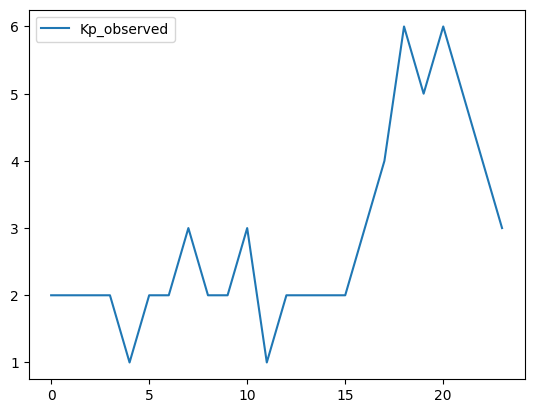

In [33]:
parameters8 = 'Kp_observed'
start = '2012-03-05T00:00:00Z'
stop  = '2012-03-08T00:00:00Z'
opts       = {'logging': True, 'usecache': True, 'cachedir': './hapicache'}
data8,meta8 = hapi(server8, dataset8, parameters8, start, stop, **opts)
#hapiplot(data8,meta8)
import pandas
# Create dataframe
df = pandas.DataFrame(data8)

# Add column to DataFrame
#df['Time'] = hapitime2datetime(data8['Time'])

# Set index
#df.set_index('Time', inplace=True)

# Rename columns
#df.columns = ['x', 'y', 'z']

display(df)

%matplotlib inline
df.plot()

In [34]:
server9 = 'https://api.helioviewer.org/hapi/Helioviewer/hapi'
dataset9 = 'LASCO_C3'
meta9 = hapi(server9,dataset9)
display(meta9)

{'startDate': '1997-02-20T23:54:37Z',
 'stopDate': '2026-02-10T11:06:13Z',
 'parameters': [{'name': 'Time',
   'type': 'isotime',
   'units': 'UTC',
   'fill': None,
   'length': 20},
  {'name': 'url',
   'type': 'string',
   'length': 255,
   'units': None,
   'description': 'Path to jp2 image',
   'fill': None}],
 'HAPI': '3.1',
 'status': {'code': 1200, 'message': 'OK'}}

In [35]:
parameters9 = 'url'
start = '2012-03-05T00:00:00Z'
stop  = '2012-03-08T00:00:00Z'
opts       = {'logging': True, 'usecache': True, 'cachedir': './hapicache'}
data9,meta9 = hapi(server9, dataset9, parameters9, start, stop, **opts)
#hapiplot(data8,meta8)
import pandas
# Create dataframe
df = pandas.DataFrame(data9)

# Add column to DataFrame
#df['Time'] = hapitime2datetime(data8['Time'])

# Set index
#df.set_index('Time', inplace=True)

# Rename columns
#df.columns = ['x', 'y', 'z']

display(df)

#%matplotlib inline
#df.plot()

hapi(): Running hapi.py version 0.2.6
hapi(): file directory = ./hapicache/api.helioviewer.org_hapi_Helioviewer_hapi
hapi(): Reading ./hapicache/api.helioviewer.org_hapi_Helioviewer_hapi
hapi(): Writing LASCO_C3___.json 
hapi(): Writing LASCO_C3___.pkl 
hapi(): Reading https://api.helioviewer.org/hapi/Helioviewer/hapi/capabilities
hapi(): Writing https://api.helioviewer.org/hapi/Helioviewer/hapi/data?id=LASCO_C3&parameters=url&time.min=2012-03-05T00:00:00Z&time.max=2012-03-08T00:00:00Z&format=binary to LASCO_C3_url_20120305T000000_20120308T000000.bin
hapi(): Reading and parsing LASCO_C3_url_20120305T000000_20120308T000000.bin
hapi(): Writing ./hapicache/api.helioviewer.org_hapi_Helioviewer_hapi/LASCO_C3_url_20120305T000000_20120308T000000.pkl
hapi(): Writing ./hapicache/api.helioviewer.org_hapi_Helioviewer_hapi/LASCO_C3_url_20120305T000000_20120308T000000.npy


,Time,url
0,b'2012-03-05T00:06:06Z',https://helioviewer.org/jp2/LASCO-C2/2012/03/0...
1,b'2012-03-05T00:18:06Z',https://helioviewer.org/jp2/LASCO-C2/2012/03/0...
2,b'2012-03-05T00:30:07Z',https://helioviewer.org/jp2/LASCO-C2/2012/03/0...
3,b'2012-03-05T00:42:05Z',https://helioviewer.org/jp2/LASCO-C2/2012/03/0...
4,b'2012-03-05T00:54:06Z',https://helioviewer.org/jp2/LASCO-C2/2012/03/0...
...,...,...
309,b'2012-03-07T22:30:26Z',https://helioviewer.org/jp2/LASCO-C2/2012/03/0...
310,b'2012-03-07T22:45:34Z',https://helioviewer.org/jp2/LASCO-C2/2012/03/0...
311,b'2012-03-07T23:00:33Z',https://helioviewer.org/jp2/LASCO-C2/2012/03/0...
312,b'2012-03-07T23:15:34Z',https://helioviewer.org/jp2/LASCO-C2/2012/03/0...


In [36]:
server10 = 'https://iswa.gsfc.nasa.gov/IswaSystemWebApp/hapi'
dataset10 = 'swpc_rtsw_plasma_P1M'
meta10 = hapi(server10,dataset10)
display(meta10)

{'HAPI': '2.0',
 'status': {'code': 1200, 'message': 'OK'},
 'title': 'NOAA/SWPC Real-Time Solar Wind Data: Builk Paramters of the Solar Wind Plasma (1-minute)',
 'description': 'Real-Time Solar Wind: Builk Paramters of the Solar Wind Plasma (1-minute) from NOAA/SWPC.  SWPC maintains the ability to instantaneously switch the spacecraft that provides the RTSW data.',
 'startDate': '2000-04-01T00:00:00Z',
 'stopDate': '2026-03-07T20:19:00Z',
 'parameters': [{'fill': 'null',
   'length': 22,
   'name': 'Time',
   'type': 'isotime',
   'units': 'UTC'},
  {'fill': '-9999.9',
   'name': 'ProtonDensity',
   'type': 'double',
   'units': 'p/cc'},
  {'fill': '-9999.9', 'name': 'BulkSpeed', 'type': 'double', 'units': 'km/s'},
  {'fill': '-100000',
   'name': 'IonTemperature',
   'type': 'double',
   'units': 'K'}]}

In [37]:
parameters10 = 'ProtonDensity,IonTemperature'
start = '2012-03-05T00:00:00Z'
stop  = '2012-03-08T00:00:00Z'
opts       = {'logging': True, 'usecache': True, 'cachedir': './hapicache'}
data10,meta10 = hapi(server10, dataset10, parameters10, start, stop, **opts)

import pandas
# Create dataframe
df10 = pandas.DataFrame(data10)

# Add column to DataFrame
#df['Time'] = hapitime2datetime(data10['Time'])

# Set index
#df.set_index('Time', inplace=True)

# Rename columns
#df.columns = ['x', 'y', 'z']

display(df10)

#%matplotlib inline
#df.plot()

hapi(): Running hapi.py version 0.2.6
hapi(): file directory = ./hapicache/iswa.gsfc.nasa.gov_IswaSystemWebApp_hapi
hapi(): Reading ./hapicache/iswa.gsfc.nasa.gov_IswaSystemWebApp_hapi
hapi(): Writing swpc_rtsw_plasma_P1M___.json 
hapi(): Writing swpc_rtsw_plasma_P1M___.pkl 
hapi(): Reading https://iswa.gsfc.nasa.gov/IswaSystemWebApp/hapi/capabilities
hapi(): Writing https://iswa.gsfc.nasa.gov/IswaSystemWebApp/hapi/data?id=swpc_rtsw_plasma_P1M&parameters=ProtonDensity,IonTemperature&time.min=2012-03-05T00:00:00Z&time.max=2012-03-08T00:00:00Z to swpc_rtsw_plasma_P1M_ProtonDensity,IonTemperature_20120305T000000_20120308T000000.csv
hapi(): Reading and parsing swpc_rtsw_plasma_P1M_ProtonDensity,IonTemperature_20120305T000000_20120308T000000.csv
hapi(): Writing ./hapicache/iswa.gsfc.nasa.gov_IswaSystemWebApp_hapi/swpc_rtsw_plasma_P1M_ProtonDensity,IonTemperature_20120305T000000_20120308T000000.pkl
hapi(): Writing ./hapicache/iswa.gsfc.nasa.gov_IswaSystemWebApp_hapi/swpc_rtsw_plasma_P1M_Prot

,Time,ProtonDensity,IonTemperature
0,b'2012-03-05T00:00:00Z',3.6,52900.0
1,b'2012-03-05T00:01:00Z',5.2,85800.0
2,b'2012-03-05T00:02:00Z',3.8,53900.0
3,b'2012-03-05T00:03:00Z',3.5,45000.0
4,b'2012-03-05T00:04:00Z',-9999.9,-100000.0
...,...,...,...
4315,b'2012-03-07T23:55:00Z',4.5,114000.0
4316,b'2012-03-07T23:56:00Z',3.3,126000.0
4317,b'2012-03-07T23:57:00Z',1.1,91400.0
4318,b'2012-03-07T23:58:00Z',2.8,149000.0


## ENLILVIZ

# Análisis de Resultados Observacionales

## Interpretación de los Datos

### Índice Dst
El índice Dst (Disturbance Storm Time) es el indicador principal de la intensidad de tormentas geomagnéticas:
- **Valores normales**: -20 a +20 nT
- **Tormenta débil**: -30 a -50 nT
- **Tormenta moderada**: -50 a -100 nT
- **Tormenta intensa**: -100 a -200 nT
- **Tormenta severa**: < -200 nT

**Análisis**: [Examinar el gráfico de Dst generado arriba e identificar el mínimo alcanzado y la fase de recuperación]

### Campo Magnético Interplanetario (ACE)
Los datos de ACE ubicado en el punto L1 (1.5 millones de km hacia el Sol) proporcionan ~1 hora de advertencia antes de que las perturbaciones lleguen a la Tierra.

**Parámetros clave**:
- **Magnitud B**: Intensidad total del campo magnético
- **Bz (componente GSM)**: Crítico para reconexión magnética (valores negativos favorecen tormentas)

### Viento Solar (Geotail y OMNI)
- **Velocidad (SW_V)**: Velocidades >500 km/s indican viento solar rápido
- **Densidad de protones (SW_P_Den)**: Incrementos indican paso de estructura comprimida
- **Presión dinámica (W)**: Compresión de la magnetosfera

### Magnetómetros Terrestres (INTERMAGNET)
Los observatorios terrestres registran las variaciones del campo geomagnético en diferentes latitudes:
- **Observatorios de alta latitud**: Mayor respuesta a actividad auroral
- **Observatorios de latitud media**: Sensibles a corriente del anillo
- **Variaciones súbitas (SCs)**: Indican llegada de choques interplanetarios

### Perturbaciones Ionosféricas (GPS ROTI)
El índice ROTI (Rate of TEC Index) mide la variabilidad del contenido total de electrones:
- **ROTI alto**: Indica irregularidades ionosféricas ("scintilación")
- **Impacto**: Degradación de precisión GPS, especialmente en regiones aurorales

### Imágenes LASCO C3
Las imágenes del coronógrafo LASCO C3 permiten visualizar las CMEs saliendo de la corona solar y estimar su dirección y velocidad.

# Resultados de Modelos CCMC

## Archivos de Resultados

Los siguientes archivos deben ser descargados de CCMC y guardados en la carpeta del proyecto:

### 1. CORHEL-CME (7 marzo 2012, 00:24:06 UTC)
- Archivo de configuración del run
- Gráficos de propagación de la CME
- Predicción de tiempo de llegada a la Tierra
- Perfil de velocidad y densidad

### 2. Tsyganenko TS05 (10 marzo 2012)
- Configuración del campo magnético
- Gráficos de líneas de campo
- Corrientes magnetosféricas
- Parámetros de entrada (Dst, presión dinámica, IMF)

### 3. IRI-2020 (10 marzo 2012)
- Perfiles de densidad electrónica
- Altura de la capa F2
- Contenido total de electrones (TEC)
- Comparación con datos GPS

### 4. Trayectorias de Rayos Cósmicos
- Gráficos de trayectorias calculadas
- Rigidez de corte geomagnético
- Efectos de la tormenta en el acceso de partículas

**Instrucciones**: Una vez obtenidos los resultados de CCMC, inserte aquí las imágenes o cargue los archivos de datos para análisis.

In [ ]:
# Ejemplo: Cargar imágenes de resultados CCMC
# Descomente y modifique según los archivos descargados

# from IPython.display import Image, display
# display(Image(filename='CORHEL_CME_20120307_results.png'))
# display(Image(filename='TS05_magnetosphere_20120310_results.png'))
# display(Image(filename='IRI2020_ionosphere_20120310_results.png'))
# display(Image(filename='cosmic_ray_trajectories_20120310_results.png'))

In [38]:
#https://enlilviz.readthedocs.io/en/latest/examples.html
import matplotlib.pyplot as plt
import enlilviz as ev
import enlilviz.plotting as evplot

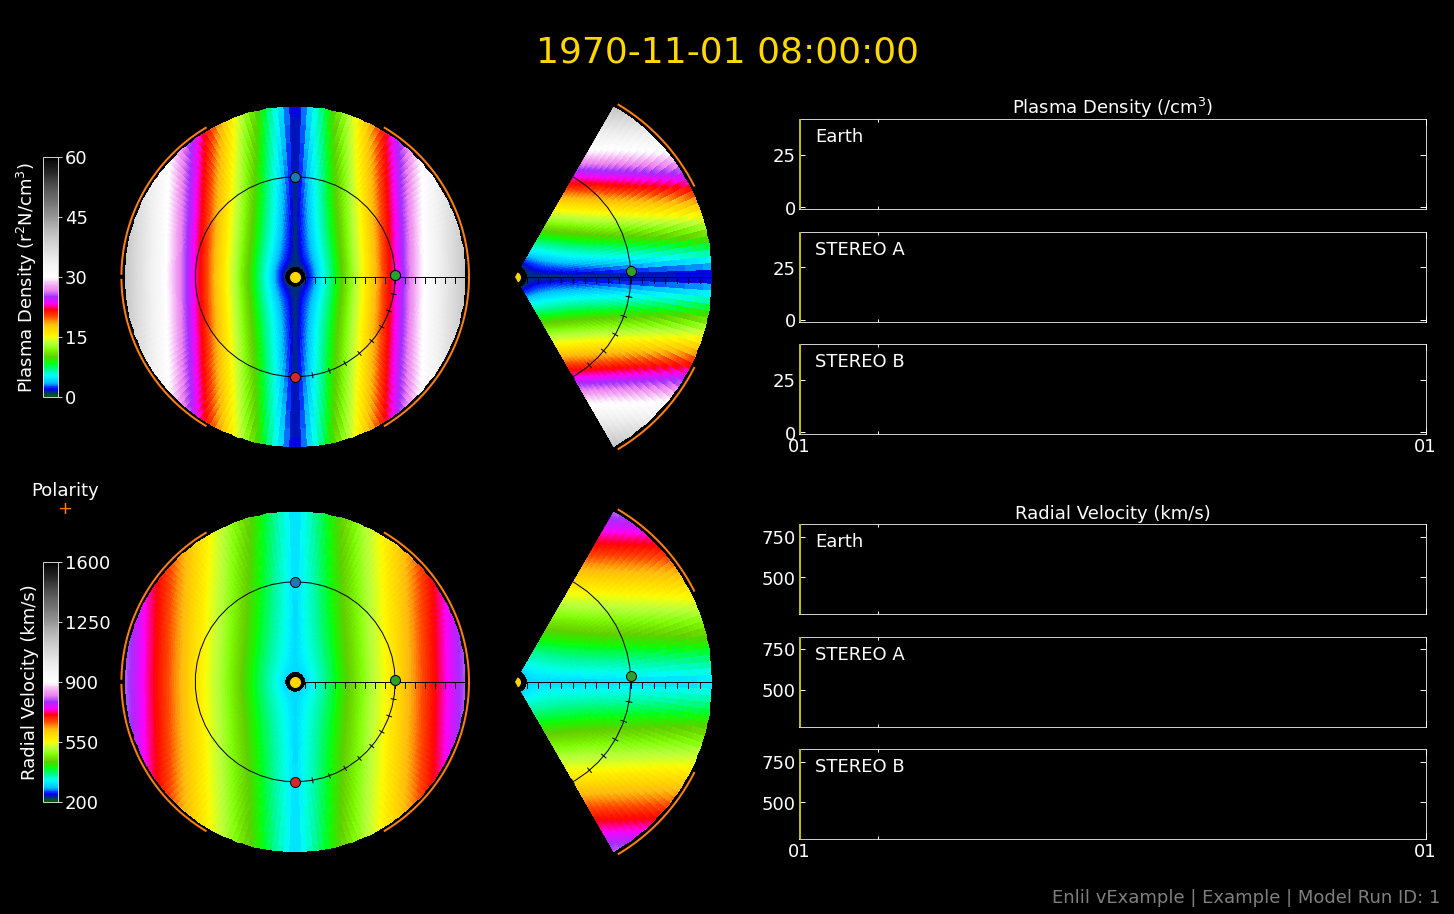

In [39]:
#Forecaster Plot
enlil_run = ev.io.load_example()
forecaster_plot = evplot.ForecasterPlot(enlil_run)
plt.show()

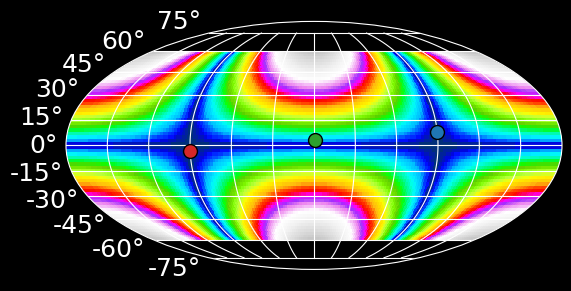

In [40]:
#Radial slice
import matplotlib.pyplot as plt
import enlilviz as ev
import enlilviz.plotting as evplot

enlil_run = ev.io.load_example()
radial_slice = evplot.RadialSlice(enlil_run, 'den')
plt.show()

In [41]:
#https://enlilviz.readthedocs.io/en/latest/readme.html#features
import matplotlib.pyplot as plt
import enlilviz as ev
import enlilviz.plotting as evplot
run=ev.read_enlil2d('C:\\Users\\yveli\\Documents\\UNAH\\OBSERVATORIO_CLIMA_ESPACIAL\\Software\\HAPI\\wsa_enlil.mrid00000000.suball.nc')

FileNotFoundError: [Errno 2] No such file or directory: '/Volumes/T7/tarea3-astroparticulas/C:\\Users\\yveli\\Documents\\UNAH\\OBSERVATORIO_CLIMA_ESPACIAL\\Software\\HAPI\\wsa_enlil.mrid00000000.suball.nc'

In [ ]:
import enlilviz.plotting as evplot

evplot.TimeSeries(run, 'Earth', 'den')

evplot.LongitudeSlice(run, 'den')

evplot.LatitudeSlice(run, 'vel')

In [ ]:
import enlilviz.plotting as evplot

evplot.TimeSeries(run, 'Earth', 'den')

evplot.LongitudeSlice(run, 'den')

evplot.LatitudeSlice(run, 'vel')

In [ ]:
forecaster = evplot.ForecasterPlot(run)
forecaster.save()

# Conclusiones

## Estado actual del análisis

### 1. Evento solar identificado
- En el período analizado se identificaron varias CMEs de halo completo con velocidades superiores a 1000 km/s.
- La CME seleccionada como evento principal fue la del **7 de marzo de 2012 a las 00:24:06 UTC**, por su alta velocidad lineal reportada (**2684 km/s**) y su clasificación de halo completo.

### 2. Evidencia observacional parcialmente procesada
- El notebook ya descarga y grafica parte de los datos necesarios para estudiar el evento, en particular el índice Dst y parámetros del campo magnético interplanetario.
- Sin embargo, la síntesis física completa todavía no está cerrada porque varias secciones siguen incompletas o con errores de ejecución.

### 3. Aspectos que aún no pueden concluirse con este notebook
- La intensidad final de la tormenta geomagnética no debe afirmarse aquí mientras no se interprete explícitamente el mínimo de Dst dentro de una ventana temporal adecuada.
- La respuesta de INTERMAGNET no debe resumirse como resultado firme mientras las consultas y gráficas correspondientes no estén resueltas.
- Los efectos ionosféricos no deben concluirse a partir de GPS ROTI porque el producto consultado en el notebook no cubre marzo de 2012.
- El valor predictivo de los modelos CCMC no puede evaluarse todavía porque sus resultados específicos del evento aún no están incorporados al análisis.

### 4. Siguiente paso científico
- Extender la ventana temporal para incluir la fase principal y de recuperación de la tormenta.
- Completar la interpretación cuantitativa de Dst, OMNI e INTERMAGNET.
- Sustituir o corregir el producto ionosférico para marzo de 2012.
- Incorporar resultados reales de CCMC antes de comparar observaciones con modelado.

---

**Nota**: En su estado actual, este notebook documenta la selección del evento y una parte del flujo de análisis, pero todavía no sustenta una conclusión completa sobre toda la cadena Sol-Tierra.

# Archivos para Subir al Repositorio GitLab

## Lista de Verificación

Para completar la tarea, los siguientes archivos deben estar en el repositorio:

### ✅ Archivos del Notebook
- [ ] `notebooks_TareaModelo.ipynb` - Este notebook con todos los análisis
- [ ] `TareaModelo.html` - Versión HTML exportada del notebook

### ✅ Resultados de Modelos CCMC

#### Modelo CORHEL-CME (7 marzo 2012, 00:24:06 UTC)
- [ ] Archivo de configuración del run (`CORHEL_config_20120307.txt`)
- [ ] Gráficos de propagación (`CORHEL_propagation_*.png`)
- [ ] Archivo de resultados (`CORHEL_results_*.dat`)

#### Modelo Tsyganenko TS05 (10 marzo 2012)
- [ ] Configuración del campo magnético (`TS05_config_20120310.txt`)
- [ ] Gráficos de líneas de campo (`TS05_fieldlines_*.png`)
- [ ] Archivo de parámetros de entrada (`TS05_input_parameters.txt`)

#### Modelo IRI-2020 (10 marzo 2012)
- [ ] Perfiles de densidad electrónica (`IRI2020_profiles_*.png`)
- [ ] Datos de TEC (`IRI2020_TEC_*.dat`)
- [ ] Configuración del run (`IRI2020_config_20120310.txt`)

#### Trayectorias de Rayos Cósmicos
- [ ] Gráficos de trayectorias (`cosmic_ray_trajectories_*.png`)
- [ ] Datos de rigidez de corte (`cutoff_rigidity_*.dat`)
- [ ] Configuración T05+IGRF (`trajectory_config_20120310.txt`)

### ✅ Datos de HAPI (Opcional - almacenados en caché)
- [ ] Carpeta `hapicache/` con datos descargados

### 📝 Instrucciones para Obtener Archivos CCMC

1. Visite las URLs de los modelos listadas en la sección de Metodología
2. Complete los formularios de solicitud "Run-on-request" o "Instant Run"
3. Ingrese las fechas y parámetros especificados
4. Espere los resultados por correo electrónico
5. Descargue todos los archivos de salida
6. Guárdelos en la carpeta del proyecto
7. Actualice las rutas en las celdas de código
8. Ejecute el notebook completo
9. Exporte a HTML
10. Suba todos los archivos a GitLab

---

## Comandos Git para Subir Archivos

```bash
# Desde la terminal en la carpeta del proyecto
git add notebooks_TareaModelo.ipynb
git add TareaModelo.html
git add CORHEL_*
git add TS05_*
git add IRI2020_*
git add cosmic_ray_*
git commit -m "Tarea modelo: Análisis evento clima espacial marzo 2012"
git push origin main
```